<a href="https://colab.research.google.com/github/marrow-Ltd/House_Prices_Practice/blob/main/House_Prices_Practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

In [2]:
from google.colab import files

uploaded = files.upload()

Saving House_Prices_Practice (1).csv to House_Prices_Practice (1).csv


In [6]:
df = pd.read_csv("House_Prices_Practice.csv")

In [7]:
print(df.head(10))
print(df.isnull().sum())

   Id  MSSubClass  LotArea Neighborhood  OverallQual  OverallCond  YearBuilt  \
0   1          30    11325        NAmes            5            2       2013   
1   2          30     3537      Edwards            1            7       2005   
2   3          30    11685        NAmes            6            1       1952   
3   4          30     8915        NAmes            9            4       2006   
4   5          30    14467      Edwards            5            1       2003   
5   6          60     3980      OldTown            9            7       2014   
6   7          70    10278      Edwards           10            1       2011   
7   8          30     8014      Somerst            6            2       2006   
8   9          70     8070      Edwards            1            8       1955   
9  10          70    12603      CollgCr            3            9       1979   

  HouseStyle  GrLivArea  BedroomAbvGr  GarageCars  SalePrice  
0     2Story     2434.0             6           3     46

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Id            200 non-null    int64  
 1   MSSubClass    200 non-null    int64  
 2   LotArea       200 non-null    int64  
 3   Neighborhood  190 non-null    object 
 4   OverallQual   200 non-null    int64  
 5   OverallCond   200 non-null    int64  
 6   YearBuilt     200 non-null    int64  
 7   HouseStyle    200 non-null    object 
 8   GrLivArea     190 non-null    float64
 9   BedroomAbvGr  200 non-null    int64  
 10  GarageCars    200 non-null    int64  
 11  SalePrice     200 non-null    int64  
dtypes: float64(1), int64(9), object(2)
memory usage: 18.9+ KB


In [9]:
print("Rows and Columns:", df.shape)

Rows and Columns: (200, 12)


In [10]:
print(df.columns)

Index(['Id', 'MSSubClass', 'LotArea', 'Neighborhood', 'OverallQual',
       'OverallCond', 'YearBuilt', 'HouseStyle', 'GrLivArea', 'BedroomAbvGr',
       'GarageCars', 'SalePrice'],
      dtype='object')


In [11]:
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


In [12]:
df = df.drop_duplicates()

print("Duplicates Removed Successfully")

Duplicates Removed Successfully


In [14]:
df.isnull().sum()

,0
Id,0
MSSubClass,0
LotArea,0
Neighborhood,10
OverallQual,0
OverallCond,0
YearBuilt,0
HouseStyle,0
GrLivArea,10
BedroomAbvGr,0


In [13]:
missing_percent = (df.isnull().sum()/len(df))*100

missing_percent.sort_values(ascending=False)

,0
Neighborhood,5.0
GrLivArea,5.0
MSSubClass,0.0
Id,0.0
LotArea,0.0
OverallQual,0.0
YearBuilt,0.0
OverallCond,0.0
HouseStyle,0.0
BedroomAbvGr,0.0


In [15]:
numerical_cols = df.select_dtypes(include=np.number).columns

categorical_cols = df.select_dtypes(include='object').columns

print("Numerical Columns")
print(numerical_cols)

print()

print("Categorical Columns")
print(categorical_cols)

Numerical Columns
Index(['Id', 'MSSubClass', 'LotArea', 'OverallQual', 'OverallCond',
       'YearBuilt', 'GrLivArea', 'BedroomAbvGr', 'GarageCars', 'SalePrice'],
      dtype='object')

Categorical Columns
Index(['Neighborhood', 'HouseStyle'], dtype='object')


In [18]:
for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

In [17]:
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [19]:
df.isnull().sum()
df.dtypes

,0
Id,int64
MSSubClass,int64
LotArea,int64
Neighborhood,object
OverallQual,int64
OverallCond,int64
YearBuilt,int64
HouseStyle,object
GrLivArea,float64
BedroomAbvGr,int64


In [20]:
# Example
df["YearBuilt"] = df["YearBuilt"].astype(int)

In [21]:
for col in categorical_cols:
    print(col)
    print(df[col].unique())
    print("-------------------------")

Neighborhood
['NAmes' 'Edwards' 'OldTown' 'Somerst' 'CollgCr']
-------------------------
HouseStyle
['2Story' '1.5Fin' '1Story']
-------------------------


In [22]:
for col in categorical_cols:
    df[col] = df[col].str.strip()

In [23]:
df.describe()

,Id,MSSubClass,LotArea,OverallQual,OverallCond,YearBuilt,GrLivArea,BedroomAbvGr,GarageCars,SalePrice
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.00000,200.000000,200.000000
mean,100.500000,46.000000,8046.850000,5.700000,5.335000,1985.150000,2393.010000,3.59500,2.100000,283385.915000
std,57.879185,19.848674,3628.766915,2.936514,3.012999,21.229246,967.648841,1.60745,1.459676,128665.406668
min,1.000000,20.000000,2013.000000,1.000000,1.000000,1950.000000,506.000000,1.00000,0.000000,55697.000000
25%,50.750000,30.000000,4918.000000,3.000000,3.000000,1967.000000,1620.500000,2.00000,1.000000,173477.000000
50%,100.500000,60.000000,8047.500000,6.000000,5.000000,1984.500000,2467.500000,3.00000,2.000000,300837.000000
75%,150.250000,60.000000,11390.250000,8.000000,8.000000,2004.000000,3173.000000,5.00000,3.000000,386770.250000
max,200.000000,70.000000,14891.000000,10.000000,10.000000,2019.000000,4000.000000,6.00000,4.000000,499399.000000


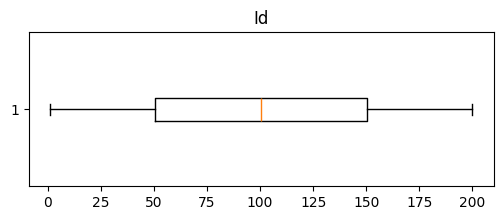

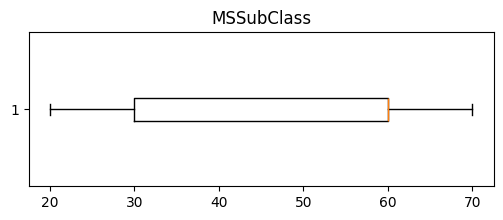

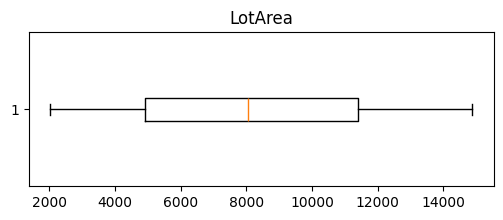

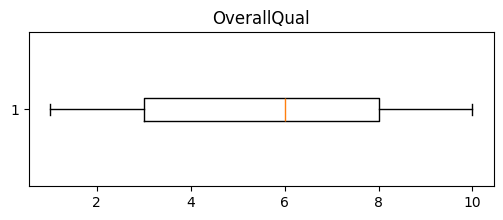

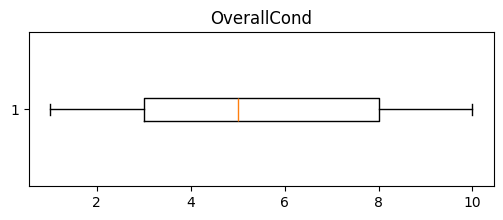

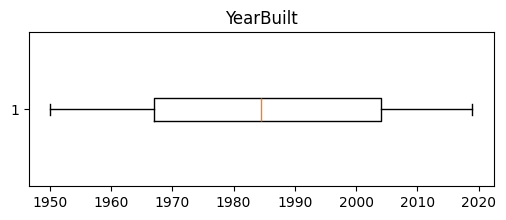

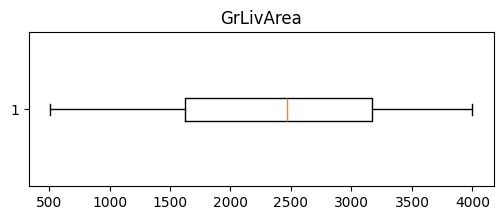

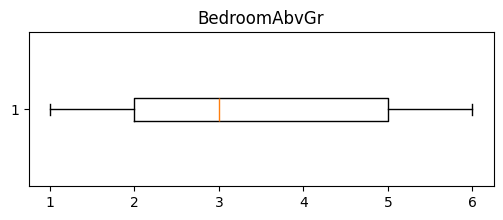

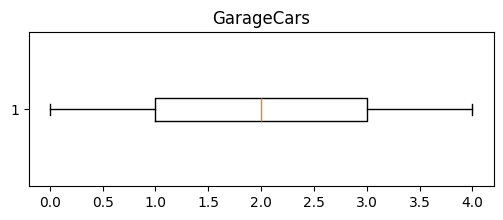

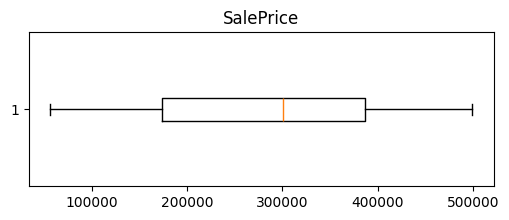

In [24]:
import matplotlib.pyplot as plt

for col in numerical_cols:
    plt.figure(figsize=(6,2))
    plt.boxplot(df[col].dropna(), vert=False)
    plt.title(col)
    plt.show()

In [25]:
for col in numerical_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

In [26]:
print(df.shape)

(200, 12)


In [27]:
df.to_csv("House_Prices_Cleaned.csv", index=False)

print("Cleaned Dataset Saved Successfully")

Cleaned Dataset Saved Successfully


In [28]:
from google.colab import files

files.download("House_Prices_Cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>